In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
FEATURES_PATH = None
for cand in [
    Path("../../datasets/processed/features.csv"),
    Path("../datasets/processed/features.csv"),
    Path("datasets/processed/features.csv"),
]:
    if cand.exists():
        FEATURES_PATH = cand.resolve()
        break

if FEATURES_PATH is None:
    raise FileNotFoundError("features.csv not found. Run 03_feature_engineering first.")

MODEL_DIR = Path("../../ml/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"📂 Features: {FEATURES_PATH}")
print(f"📂 Models  : {MODEL_DIR}")

📂 Features: C:\Users\ASUS\OneDrive\Desktop\claude-test\smart-retail-intelligence-platform\datasets\processed\features.csv
📂 Models  : ..\..\ml\models


In [3]:
feat = pd.read_csv(FEATURES_PATH, low_memory=False)
feat["ds"] = pd.to_datetime(feat["ds"])
feat = feat.sort_values("ds").reset_index(drop=True)

print(f"Rows: {len(feat):,} | Range: {feat['ds'].min().date()} → {feat['ds'].max().date()}")
print(feat["split"].value_counts().to_dict())
feat.head(3)

Rows: 1,065 | Range: 2021-01-31 → 2023-12-31
{'train': 736, 'test': 165, 'val': 164}


,ds,split,y,y_revenue,y_quantity,y_profit,y_transactions,year,month,day,day_of_week,week_of_year,quarter,is_weekend,is_month_start,is_month_end,month_sin,month_cos,dow_sin,dow_cos,...,roll_max_14,roll_mean_30,roll_std_30,roll_min_30,roll_max_30,promo_share,festival_share,holiday_share,avg_discount,avg_stock,stockout_share,n_stores,n_products,is_promo_day,is_festival_day,is_holiday_day,high_discount_day,high_stockout_day,weekend_x_promo,festival_x_promo
0,2021-01-31,train,"9,310,912.43","9,310,912.43",1509,"1,993,427.54",272,2021,1,31,6,4,1,1,0,1,0.50,0.87,-0.78,0.62,...,"16,808,163.46","8,619,262.86","2,742,577.66","5,796,841.72","16,808,163.46",0.48,0.00,0.00,0.13,100.37,0.02,10,148,1,0,0,0,0,1,0
1,2021-02-01,train,"7,859,465.60","7,859,465.60",909,"1,770,156.16",273,2021,2,1,0,5,1,0,1,0,0.87,0.50,0.00,1.00,...,"16,808,163.46","8,652,505.49","2,744,788.49","5,796,841.72","16,808,163.46",0.52,0.00,0.00,0.14,101.59,0.00,10,144,1,0,0,0,0,0,0
2,2021-02-02,train,"6,899,503.98","6,899,503.98",842,"1,348,847.95",246,2021,2,2,1,5,1,0,0,0,0.87,0.50,0.78,0.62,...,"16,808,163.46","8,505,535.21","2,661,261.07","5,796,841.72","16,808,163.46",0.52,0.00,0.00,0.14,104.37,0.02,10,145,1,0,0,0,0,0,0


In [4]:
# Numeric features only (no leakage of target)
exclude = {
    "ds", "split", "y", "y_revenue", "y_quantity", "y_profit", "y_transactions",
    "season",  # use season_enc instead
}

feature_cols = [
    c for c in feat.columns
    if c not in exclude and pd.api.types.is_numeric_dtype(feat[c])
]

print(f"Using {len(feature_cols)} features:")
print(feature_cols)

Using 47 features:
['year', 'month', 'day', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'season_enc', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_qty_1', 'lag_qty_7', 'roll_mean_7', 'roll_std_7', 'roll_min_7', 'roll_max_7', 'roll_mean_14', 'roll_std_14', 'roll_min_14', 'roll_max_14', 'roll_mean_30', 'roll_std_30', 'roll_min_30', 'roll_max_30', 'promo_share', 'festival_share', 'holiday_share', 'avg_discount', 'avg_stock', 'stockout_share', 'n_stores', 'n_products', 'is_promo_day', 'is_festival_day', 'is_holiday_day', 'high_discount_day', 'high_stockout_day', 'weekend_x_promo', 'festival_x_promo']


In [5]:
def make_xy(df, cols):
    X = df[cols].copy()
    y = df["y"].astype(float).values
    # fill any leftover NaN safely
    X = X.fillna(X.median(numeric_only=True))
    return X, y

train = feat[feat["split"] == "train"].copy()
val   = feat[feat["split"] == "val"].copy()
test  = feat[feat["split"] == "test"].copy()

X_train, y_train = make_xy(train, feature_cols)
X_val, y_val     = make_xy(val, feature_cols)
X_test, y_test   = make_xy(test, feature_cols)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (736, 47) | Val: (164, 47) | Test: (165, 47)


In [6]:
def metrics_dict(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100)
    return {"MAE": float(mae), "RMSE": rmse, "MAPE": mape, "n": int(len(y_true))}

def eval_model(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te):
    out = {"model": name}
    out["train"] = metrics_dict(y_tr, model.predict(X_tr))
    if len(X_v):
        out["val"] = metrics_dict(y_v, model.predict(X_v))
    if len(X_te):
        out["test"] = metrics_dict(y_te, model.predict(X_te))
    return out

In [7]:
# Ridge is more stable than plain LinearRegression with many features
lin_model = Ridge(alpha=1.0, random_state=42)
lin_model.fit(X_train, y_train)

lin_metrics = eval_model(
    "ridge", lin_model,
    X_train, y_train, X_val, y_val, X_test, y_test
)

print("Ridge metrics:")
for split in ["train", "val", "test"]:
    if split in lin_metrics:
        m = lin_metrics[split]
        print(f"  {split:5s}  MAE={m['MAE']:,.0f}  RMSE={m['RMSE']:,.0f}  MAPE={m['MAPE']:.2f}%")

Ridge metrics:
  train  MAE=842,837  RMSE=1,099,637  MAPE=10.17%
  val    MAE=878,801  RMSE=1,138,419  MAPE=10.74%
  test   MAE=896,566  RMSE=1,123,164  MAPE=11.10%


In [8]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
)
rf_model.fit(X_train, y_train)

rf_metrics = eval_model(
    "random_forest", rf_model,
    X_train, y_train, X_val, y_val, X_test, y_test
)

print("Random Forest metrics:")
for split in ["train", "val", "test"]:
    if split in rf_metrics:
        m = rf_metrics[split]
        print(f"  {split:5s}  MAE={m['MAE']:,.0f}  RMSE={m['RMSE']:,.0f}  MAPE={m['MAPE']:.2f}%")

Random Forest metrics:
  train  MAE=567,218  RMSE=924,057  MAPE=6.61%
  val    MAE=886,783  RMSE=1,486,315  MAPE=10.29%
  test   MAE=1,006,711  RMSE=1,525,232  MAPE=11.40%


,feature,importance
45,weekend_x_promo,0.21
6,is_weekend,0.18
3,day_of_week,0.18
32,promo_share,0.12
11,dow_sin,0.05
35,avg_discount,0.04
39,n_products,0.03
4,week_of_year,0.03
34,holiday_share,0.01
41,is_festival_day,0.01


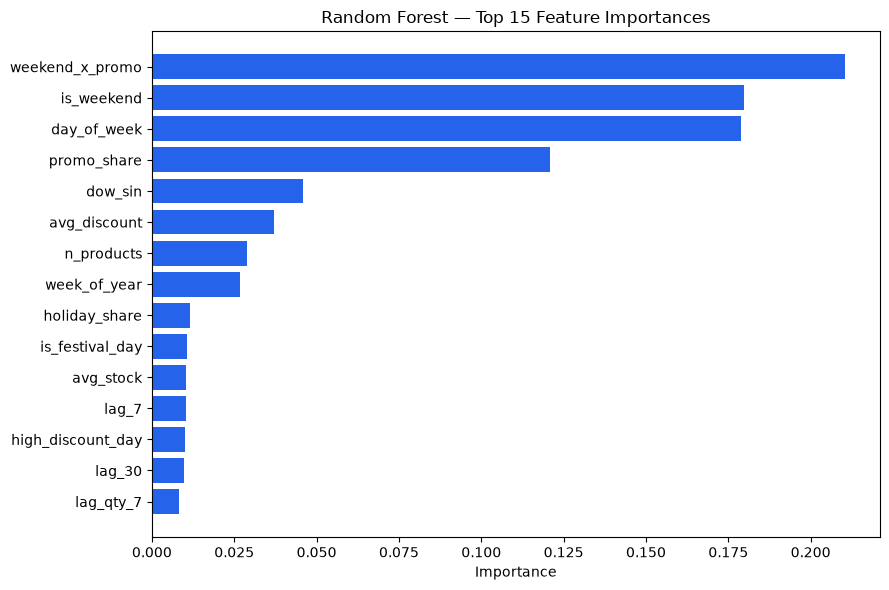

In [9]:
imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(imp.head(15))

fig, ax = plt.subplots(figsize=(9, 6))
top = imp.head(15).iloc[::-1]
ax.barh(top["feature"], top["importance"], color="#2563eb")
ax.set_title("Random Forest — Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

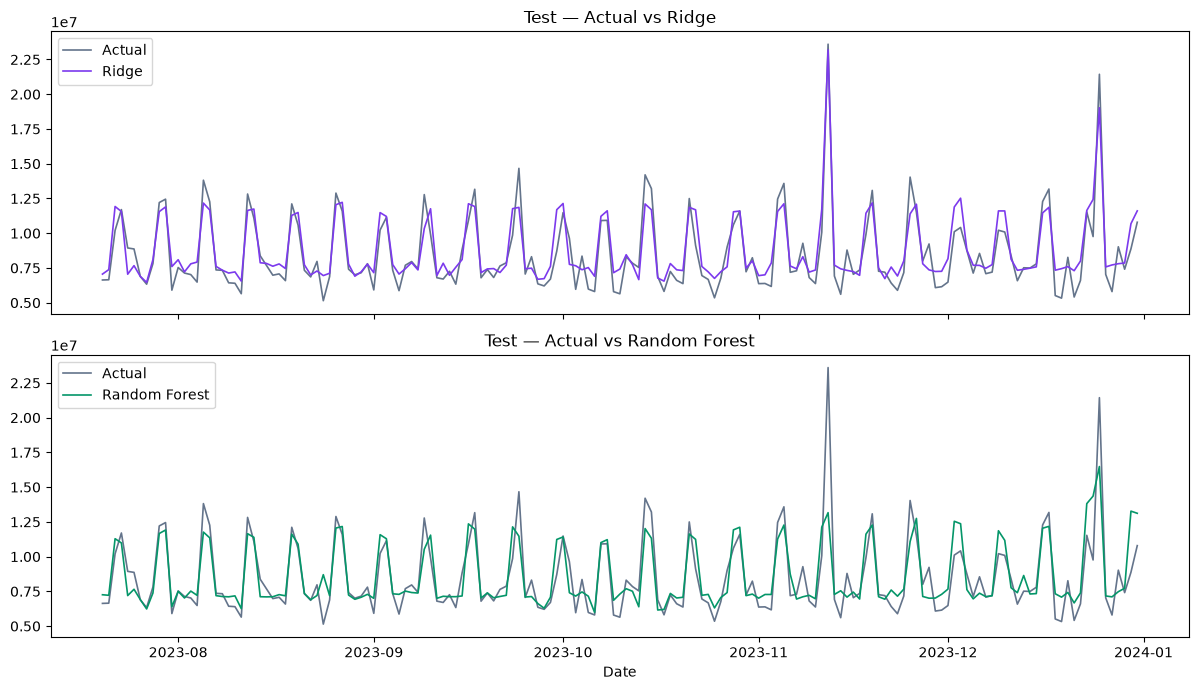

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

if len(test):
    yhat_lin = lin_model.predict(X_test)
    yhat_rf = rf_model.predict(X_test)
    ds_test = test["ds"].values

    axes[0].plot(ds_test, y_test, color="#64748b", label="Actual", linewidth=1.2)
    axes[0].plot(ds_test, yhat_lin, color="#7c3aed", label="Ridge", linewidth=1.2)
    axes[0].set_title("Test — Actual vs Ridge")
    axes[0].legend()

    axes[1].plot(ds_test, y_test, color="#64748b", label="Actual", linewidth=1.2)
    axes[1].plot(ds_test, yhat_rf, color="#059669", label="Random Forest", linewidth=1.2)
    axes[1].set_title("Test — Actual vs Random Forest")
    axes[1].legend()
    axes[1].set_xlabel("Date")
else:
    axes[0].set_visible(False)
    axes[1].text(0.5, 0.5, "No test rows", ha="center")

plt.tight_layout()
plt.show()

In [11]:
# Final models for production: train + val
train_val = feat[feat["split"].isin(["train", "val"])].copy()
X_tv, y_tv = make_xy(train_val, feature_cols)

final_lin = Ridge(alpha=1.0, random_state=42)
final_lin.fit(X_tv, y_tv)

final_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
)
final_rf.fit(X_tv, y_tv)

lin_bundle = {
    "model": final_lin,
    "feature_cols": feature_cols,
    "model_type": "ridge",
    "metrics": lin_metrics,
}
rf_bundle = {
    "model": final_rf,
    "feature_cols": feature_cols,
    "model_type": "random_forest",
    "metrics": rf_metrics,
    "feature_importance": imp.to_dict(orient="records"),
}

lin_path = MODEL_DIR / "linear_model.pkl"
rf_path = MODEL_DIR / "random_forest_model.pkl"

with open(lin_path, "wb") as f:
    pickle.dump(lin_bundle, f)
with open(rf_path, "wb") as f:
    pickle.dump(rf_bundle, f)

all_metrics = {
    "ridge": lin_metrics,
    "random_forest": rf_metrics,
    "feature_cols": feature_cols,
}
with open(MODEL_DIR / "baseline_metrics.json", "w") as f:
    json.dump(all_metrics, f, indent=2)

print(f"✅ Saved {lin_path}")
print(f"✅ Saved {rf_path}")
print(f"✅ Saved {MODEL_DIR / 'baseline_metrics.json'}")
print("\nNext → 05_xgboost_training.ipynb")

✅ Saved ..\..\ml\models\linear_model.pkl
✅ Saved ..\..\ml\models\random_forest_model.pkl
✅ Saved ..\..\ml\models\baseline_metrics.json

Next → 05_xgboost_training.ipynb


In [12]:
with open(MODEL_DIR / "random_forest_model.pkl", "rb") as f:
    loaded = pickle.load(f)

print("Type:", loaded["model_type"])
print("Features:", len(loaded["feature_cols"]))
print("Val MAPE:", loaded["metrics"].get("val", {}).get("MAPE"))
print("✅ Baseline pipeline OK")


Type: random_forest
Features: 47
Val MAPE: 10.29032387042222
✅ Baseline pipeline OK
